### Tutorial B4: Taylor <i>In Silico</i> Saturation Mutagenesis (ISM)

The <i>in silico saturation mutagenesis</i> (ISM) method (discussed in tutorial B4) allows one to quantify the influence of each letter from the alphabet at each position in the sequence on the models's predictions. At a high level, ISM operates by changing the character at each position to each other potential character, one at a time, and evaluating the difference in prediction before and after the substitution. This difference is interpreted as a form of importance/attribution, with a higher magnitude value meaning that changing the character has a large impact and is likely very important.
However, as the state-of-the-art models continue to model larger input sequences (e.g., >100Kb), it is becoming computationally prohibitive to apply ISM. In the article [https://doi.org/10.1016/j.isci.2024.110807] was suggested to use first-order Taylor approximation to compute ISM values using the model’s gradient from a single forward pass for each sequence. It was shown that Taylor approximated ISM (TISM) approximations speed up computations of ISM values by a factor L times three divided by the batch size. TISM derived attribution maps highly resemble attribution maps from ISM, more than the models’ gradient as it is. TISM values were shown to be robust across different models, random initializations, training parameters, and dataset sizes.

Although this function will, by default, provide an attribution score, one can also get the underlying gradients after substitutions. This functionality means that if you disagree with the specific distance function used to score importances, or you want to do something else with the gradients, you can still use the same function.

Let's demonstrate how to use this using Beluga / DeepSEA.

In [ ]:
import torch
from model import Beluga

model = Beluga()
model.load_state_dict(torch.load("deepsea.beluga.torch", weights_only=False))


<All keys matched successfully>

First,  we need a sequence to analyze. Because TISM is usually performed on actual genomic sequence (or constructs), we will pull a sequence from the human genome. You will need to download the hg38 fasta file from https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz and unzip it to run the rest of this notebook yourself.

In [ ]:
import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute

seq = pyfaidx.Fasta("hg38.fa")["chr1"][28328000 : 28328000 + 2000].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float()
X.shape


torch.Size([1, 4, 2000])

#### Basic Usage

We can run TISM on a sequence (or a batch of sequences) using the `tism` function. This function takes in a model, the batch of sequences, and other optional arguments, and returns the TISM attribution values.

In [ ]:
import sys

module_path = "../../tangermeme"

if module_path not in sys.path:
    sys.path.insert(0, module_path)

from tism import tism

X_attr = tism(model, X)
X_attr.shape


torch.Size([1, 4, 2000])

`tism` function has the similar interface as `saturation_mutagenesis` function, all of benefits of that function are available here as well, e.g., moving the model and data to/from a device, automatic batching of examples, etc. For example, we can do the same calculations on a CPU.

In [ ]:
X_attr = tism(model, X, device="cpu")


/home/labanovvlad/envs/tangermeme/lib/python3.12/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)


As the helpful warning above mentions, we can also use alternative dtypes to speed up the computation at the cost of precision.

In [ ]:
X_attr = tism(model, X, dtype="float16")


If we have additional arguments to pass into the model -- even arguments that change from example to example, we can use the `args` keyword and pass in a tuple, just like with the `saturation_mutagenesis` function. This is commented out because the Beluga model does not take in additional arguments, but provided in case one is using a model that does.

In [ ]:
# X_attr = tism(model, X, args=(arg0, arg1 ...))


#### Focusing on a subset of tasks or just one task

Sometimes, you do not want to average your attributions across all tasks. DeepSEA has thousands of tasks that represent diverse activity -- averaging attributions across transcription, protein binding, and histone modification outputs would be noisy and difficult to deconvolve into what patterns influence what output. Usually, you would like to focus on a single output or a small number of outputs at a time. There are two ways to do this with `tangermeme`. The first is to write a custom class that slices out only the outputs you want. This approach is very flexible because it allows you to do anything you want to the outputs of the trained models, e.g., transform or aggregate them in some custom way in addition to just slicing. In the example below we will be slicing out only one task that we care about. Keep in mind that the resulting tensor must still have two dimensions where the second dimension is the number of targets, even if the number of targets is 1.

In [ ]:
class SliceWrapper(torch.nn.Module):
    def __init__(self, model, target):
        super(SliceWrapper, self).__init__()
        self.model = model
        self.target = target

    def forward(self, X):
        return self.model(X)[:, self.target : self.target + 1]


wrapper = SliceWrapper(model, target=57)
X_attr = tism(wrapper, X)  # Note that we are passing in `wrapper` not `model`
X_attr.shape


torch.Size([1, 4, 2000])

If your model is like DeepSEA in the sense that it returns one tensor and you want to focus on only one output at a time you can also pass in the `target` parameter. This will do the exact same thing as the code above but only works when you have a single tensor being returned and want to slice out a single output.

In [ ]:
X_attr2 = tism(model, X, target=57)  # Note that we are passing in `model` not `wrapper`
torch.abs(X_attr - X_attr2).max()


tensor(1.4901e-08)

Note that we are getting the similar result using the `target` parameter or writing a custom wrapper.

We can then plot these attributions using the same `plot_logo` function we used to visualize the DeepLIFT/SHAP attributions. This function wraps `logomaker` with some additional functionality that we won't be using in this example. If we want to focus on attributions for the observed nucleotides, as opposed to hypothetical attributions of nucleotide substitutions, we can multiply by the one-hot encoded sequence. 

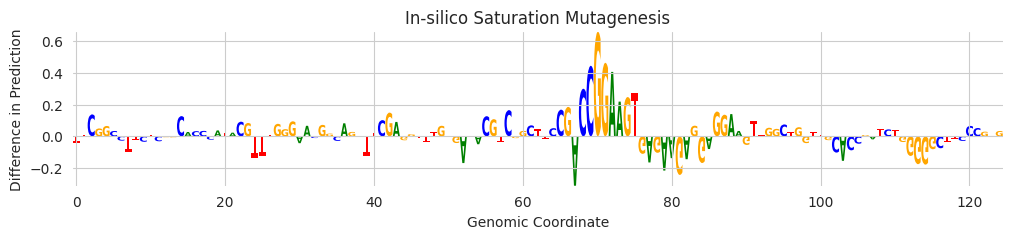

In [ ]:
from matplotlib import pyplot as plt
import seaborn

seaborn.set_style("whitegrid")
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo(X_attr[0, :, 950:1075])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()


The attributions are highlighting several interesting patterns here. Most notably, we see one motif strongly being highlighted, which is likely being bound by a member of the ELF/ELK family, and a second motif nearby that does not have the leading two C's and also has a much lower attribution value. This second motif may be a weak ELF/ELK hit, or it could be a related ETV motif. However, the attributions for the rest of the sequence are not as clean. This is, unfortunately, in part due to DeepSEA generally having messier attributions than other models for technical reasons.

Just to confirm that some of these features are real and that the implementation is working, we can consider the DeepLIFT/SHAP attributions at this locus as well. We do not expect the exact same magnitudes for the characters but the two methods should largely agree on the regions of high contiguous attribution.

In [ ]:
"""from tangermeme.deep_lift_shap import deep_lift_shap

X_attr3 = deep_lift_shap(model, X, target=57)

plt.figure(figsize=(12, 2))
plot_logo(X_attr3[0, :, 950:1075])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()
"""


'from tangermeme.deep_lift_shap import deep_lift_shap\n\nX_attr3 = deep_lift_shap(model, X, target=57)\n\nplt.figure(figsize=(12, 2))\nplot_logo(X_attr3[0, :, 950:1075])\n\nplt.xlabel("Genomic Coordinate")\nplt.ylabel("Difference in Prediction")\nplt.title("In-silico Saturation Mutagenesis")\nplt.show()\n'

Looks like both of the features still have high attribution values, although there is more noise on the flanks of both motifs. 

#### Hypothetical attributions

By default, `tism` only reports the attribution values for characters actually present in the sequence. This is to match the most common use-case of attribution algorithms where one wants to highlight the characters in a sequence driving predictions. However, just like with `deep_lift_shap`, we can get the hypothetical attributions of characters that were not actually present in the original sequence. In fact, these values have to be calculated as part of the tism algorithm because we need them to know what the position-specific mean values are to normalize by. We can get them the same way we get them in `deep_lift_shap`, by passing in `hypothetical=True`.

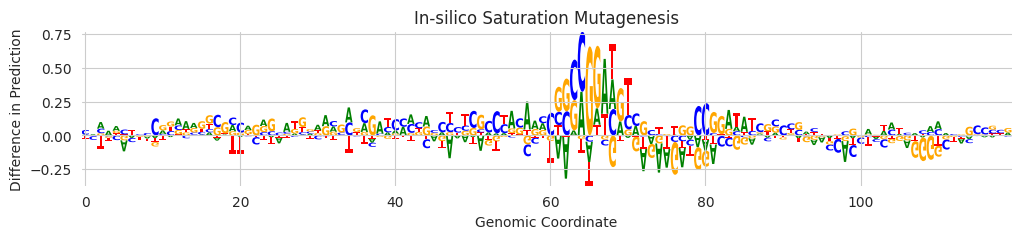

In [ ]:
X_attr = tism(model, X, target=57, hypothetical=True)

plt.figure(figsize=(12, 2))
plot_logo(X_attr[0, :, 955:1075])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()


#### Getting the raw outputs

Sometimes, you'd prefer to just get the raw gradients after each substitution. These predictions might be valuable in some other context or, perhaps, you want to implement your own method for aggregating them into a score function.

In [ ]:
y_tism = tism(model, X, raw_outputs=True)
y_tism.shape


torch.Size([1, 2000, 4, 2000])

#### Windowed TISM

Sometimes, the sequences that you are evaluating are very long or there are too many of them and so you do not have the compute power to comprehensively run TISM everywhere. Sometimes, there is only a small window of interest and it would be a waste to run TISM everywhere. For example, you may have a list of motif hits and you want to evaluate each one to see whether that motif is driving activity without having to waste time substitutions outside those motif hits. For both situations you may want to run TISM only on a portion of the input window instead of on everything. `tism` allows you to run ISM from only a start coordinate to an end coordinate and save time.

In [ ]:
X_attr_w = tism(model, X, start=955, end=1075, target=57)
X_attr_w.shape


torch.Size([1, 4, 2000])

The results will be different to performing TISM across the entire example and then subsetting on only the positions of interest. This is because changing one position of the sequence affects gradient of the whole sequence.

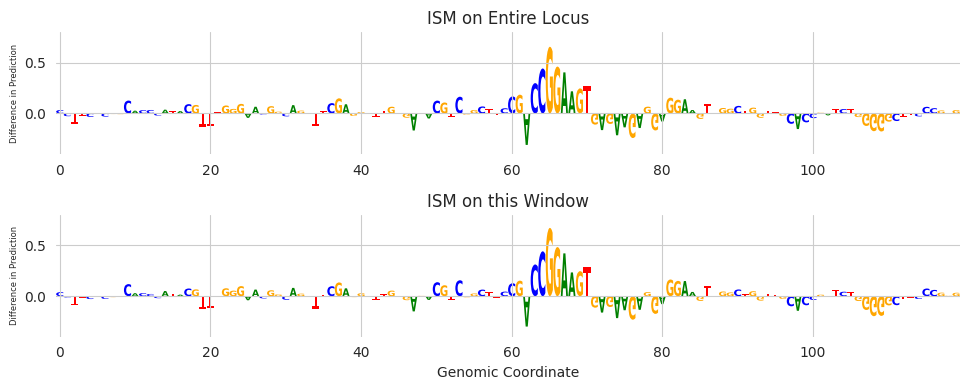

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(211)
plot_logo((X_attr * X)[0, :, 955:1075])
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on Entire Locus")
plt.ylim(-0.4, 0.8)

plt.subplot(212)
plot_logo((X_attr_w[:, :, 955:1075] * X[:, :, 955:1075])[0])
plt.ylim(-0.4, 0.8)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()


We can time these two versions to see what sort of speed gain we get.

In [15]:
%timeit -n 1 -r 1 tism(model, X, start=955, end=1075, target=57)
%timeit -n 1 -r 1 tism(model, X, target=57)


50.5 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
811 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


As you might expect, we get roughly a ~16x speed gain when only looking at ~5% of the sequence.

As an example of a situation where this would be useful: imagine that you have a set of coordinates you want to investigate. Perhaps, these are motif hits according to a method like FIMO. You can quickly calculate TISM scores for each motif by running windowed TISM for each set of coordinates and summing the attribution values across the width.

In [ ]:
import numpy
import pandas

starts = numpy.array(
    [0, 720, 990, 1050, 1100, 1500]
)  # Only 1050 is an actual motif, the rest are for demonstration
y_attr = []

for start in starts:
    end = start + 20

    X_attr_ = (
        tism(model, X, start=start, end=end, target=57)[:, :, start:end]
        * X[:, :, start:end]
    )
    y_attr.append(X_attr_.sum().item())

df = pandas.DataFrame({"start": starts, "end": starts + 20, "score": y_attr})
df


,start,end,score
0,0,20,0.001248
1,720,740,-0.016109
2,990,1010,0.383366
3,1050,1070,-0.899803
4,1100,1120,-0.068759
5,1500,1520,0.106083


The actual motif, from 1050-1070, has significantly higher attribution than the others. And it only took ~1-2 seconds to calculate all of these on a CPU, rather than the ~minute that it takes to calculate across the entire sequence.